# Lab3 - ML Models (Classification) & Evaluation
ML Models:
Linear Classficiation

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

# create dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# convert numeric labels to species names
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


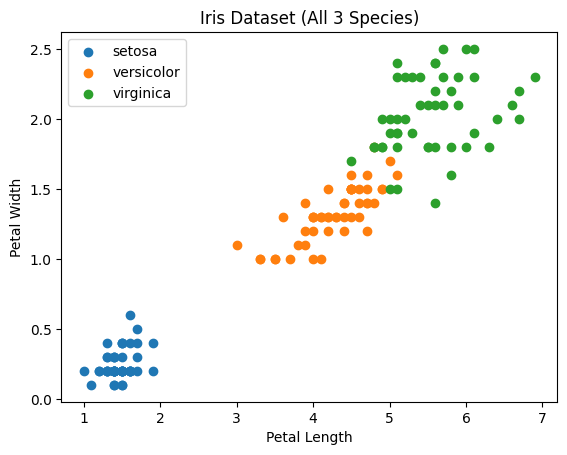

In [2]:
import matplotlib.pyplot as plt

for species in df["species"].unique():
    subset = df[df["species"] == species]

    plt.scatter(subset["petal length (cm)"],subset["petal width (cm)"],label=species)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Dataset (All 3 Species)")
plt.legend()

plt.show()

### Choosing two species for binary classification

In [3]:
df_binary = df[df["species"].isin(["virginica", "versicolor"])] # virginica , setosa

### Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X = df_binary.drop(columns="species")
y = df_binary["species"] # class labels /targetr

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#train_test_split (*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

In [5]:
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
61,5.9,3.0,4.2,1.5
97,6.2,2.9,4.3,1.3
135,7.7,3.0,6.1,2.3
78,6.0,2.9,4.5,1.5
143,6.8,3.2,5.9,2.3
...,...,...,...,...
110,6.5,3.2,5.1,2.0
121,5.6,2.8,4.9,2.0
64,5.6,2.9,3.6,1.3
142,5.8,2.7,5.1,1.9


In [6]:
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
133,6.3,2.8,5.1,1.5
103,6.3,2.9,5.6,1.8
120,6.9,3.2,5.7,2.3
95,5.7,3.0,4.2,1.2
94,5.6,2.7,4.2,1.3
89,5.5,2.5,4.0,1.3
72,6.3,2.5,4.9,1.5
130,7.4,2.8,6.1,1.9
60,5.0,2.0,3.5,1.0
50,7.0,3.2,4.7,1.4


In [7]:
y_train

61     versicolor
97     versicolor
135     virginica
78     versicolor
143     virginica
          ...    
110     virginica
121     virginica
64     versicolor
142     virginica
101     virginica
Name: species, Length: 70, dtype: category
Categories (3, object): ['setosa', 'versicolor', 'virginica']

In [8]:
y_test

133     virginica
103     virginica
120     virginica
95     versicolor
94     versicolor
89     versicolor
72     versicolor
130     virginica
60     versicolor
50     versicolor
68     versicolor
80     versicolor
123     virginica
83     versicolor
140     virginica
54     versicolor
126     virginica
127     virginica
62     versicolor
81     versicolor
105     virginica
138     virginica
76     versicolor
92     versicolor
119     virginica
65     versicolor
90     versicolor
146     virginica
59     versicolor
122     virginica
Name: species, dtype: category
Categories (3, object): ['setosa', 'versicolor', 'virginica']

## Train a Linear Classifier

In [9]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=10000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1)) #-0.5-0.5
        self.bias = 0
        y = y.reshape(-1,1)

        for _ in range(self.n_iterations):
            # linear model
            z = np.dot(X, self.weights) + self.bias
            # sigmoid
            y_pred = self._sigmoid(z)
            # gradients
            dw = np.dot(X.T, (y_pred - y)) / n_samples
            db = np.sum(y_pred - y) / n_samples
            # update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X, threshold=0.5):
        z = np.dot(X, self.weights) + self.bias
        probs = self._sigmoid(z)
        return (probs >= threshold).astype(int)

### Min-Max normalization

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Apply Min-Max normalization based on TRAIN
X_train_Max_Min_scaled = (X_train - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0))
X_test_Max_Min_scaled = (X_test - X_train.min(axis=0)) / (X_train.max(axis=0) - X_train.min(axis=0)) 


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


model = LogisticRegressionScratch()
model.fit(X_train_Max_Min_scaled, y_train)



y_pred = model.predict(X_test_Max_Min_scaled)

# flatten y_pred to 1D
y_pred_flat = y_pred.ravel()   # or y_pred.flatten()
results = pd.DataFrame({'Actual': y_test,
                        'Predicted': y_pred_flat})
results 

,Actual,Predicted
0,1,0
1,1,1
2,1,1
3,0,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [11]:
print("Accuracy with Min-Max normalization:", (y_pred_flat == y_test).mean())
print("Accuracy:", accuracy_score(y_test, y_pred_flat))
# Parameter 
print("Weights:")
print(model.weights)

print("Bias:")
print(model.bias)

Accuracy with Min-Max normalization: 0.9333333333333333
Accuracy: 0.9333333333333333
Weights:
[[ 0.59691537]
 [-0.82088845]
 [ 2.67546805]
 [ 4.4159989 ]]
Bias:
-3.1147269130676123


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Apply Min-Max normalization based on TRAIN


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegressionScratch()
model.fit(X_train_scaled, y_train)



y_pred = model.predict(X_test_scaled)

# flatten y_pred to 1D
y_pred_flat = y_pred.ravel()   # or y_pred.flatten()
results = pd.DataFrame({'Actual': y_test,
                        'Predicted': y_pred_flat})
results 

,Actual,Predicted
0,1,0
1,1,1
2,1,1
3,0,0
4,0,0
5,0,0
6,0,1
7,1,1
8,0,0
9,0,0


In [13]:
from sklearn.metrics import accuracy_score


print("Accuracy with z-score normalization:", (y_pred_flat == y_test).mean())
print("Accuracy:", accuracy_score(y_test, y_pred_flat))

print("Weights:")
print(model.weights)

print("Bias:")
print(model.bias)

Accuracy with z-score normalization: 0.8666666666666667
Accuracy: 0.8666666666666667
Weights:
[[-0.36806379]
 [-1.34058499]
 [ 3.21067787]
 [ 3.2622505 ]]
Bias:
0.3200537833968037


### LogisticRegression--Scikit-Learn

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X = df_binary.drop(columns="species")
y = df_binary["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Predicted Classes

In [15]:
print("Classes:")
print(model.classes_)

Classes:
['versicolor' 'virginica']


In [16]:
y_pred = model.predict(X_test)
result = pd.DataFrame({'Actual': y_test,
                        'Predicted': y_pred})
result

,Actual,Predicted
133,virginica,versicolor
103,virginica,virginica
120,virginica,virginica
95,versicolor,versicolor
94,versicolor,versicolor
89,versicolor,versicolor
72,versicolor,virginica
130,virginica,virginica
60,versicolor,versicolor
50,versicolor,versicolor


### Probability for each class:

In [17]:
y_probs = model.predict_proba(X_test)

print(y_probs[:5])

[[0.53834396 0.46165604]
 [0.08709261 0.91290739]
 [0.01448236 0.98551764]
 [0.98609497 0.01390503]
 [0.95474048 0.04525952]]


In [18]:
print("Class mapping:", model.classes_)
print("\nSample probabilities and predicted class:")
for i in range(10):
    probs_str = ", ".join([f"{cls}: {y_probs[i, idx]:.2f}" for idx, cls in enumerate(model.classes_)])
    pred_class = model.predict(X_test[i:i+1])[0]
    print(f"Sample {i+1} -> {probs_str} | Predicted class: {pred_class}")

Class mapping: ['versicolor' 'virginica']

Sample probabilities and predicted class:
Sample 1 -> versicolor: 0.54, virginica: 0.46 | Predicted class: versicolor
Sample 2 -> versicolor: 0.09, virginica: 0.91 | Predicted class: virginica
Sample 3 -> versicolor: 0.01, virginica: 0.99 | Predicted class: virginica
Sample 4 -> versicolor: 0.99, virginica: 0.01 | Predicted class: versicolor
Sample 5 -> versicolor: 0.95, virginica: 0.05 | Predicted class: versicolor
Sample 6 -> versicolor: 0.96, virginica: 0.04 | Predicted class: versicolor
Sample 7 -> versicolor: 0.49, virginica: 0.51 | Predicted class: virginica
Sample 8 -> versicolor: 0.02, virginica: 0.98 | Predicted class: virginica
Sample 9 -> versicolor: 0.99, virginica: 0.01 | Predicted class: versicolor
Sample 10 -> versicolor: 0.94, virginica: 0.06 | Predicted class: versicolor


### Aaccuracy , Weights , Bias

In [19]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Weights:")
print(model.coef_)

print("Bias:")
print(model.intercept_)

Accuracy: 0.9
Weights:
[[-0.1311045  -0.74011638  2.11285313  2.1160066 ]]
Bias:
[0.26970042]


C:\Users\Dell\AppData\Local\Temp\ipykernel_6308\1085155763.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  df_binary.loc[:, 'species'] = df_binary['species'].map({'virginica': 0,'versicolor': 1})


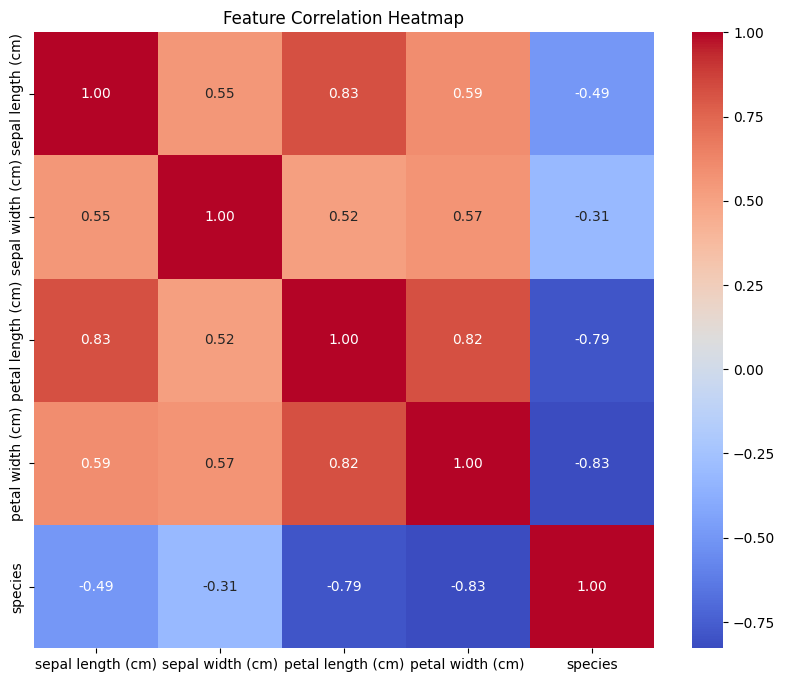

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
# Correlation matrix
df_binary.loc[:, 'species'] = df_binary['species'].map({'virginica': 0,'versicolor': 1})

corr = df_binary.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

### Choosing the highest Correlated Features with the outcome

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import accuracy_score

X = df_binary[["petal length (cm)", "petal width (cm)"]]
y = df_binary["species"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X.columns)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X.columns)

# Train model
model_2d = LogisticRegression()
model_2d.fit(X_train_scaled, y_train)

# Evaluation
accuracy = model_2d.score(X_test_scaled, y_test)
print("Accuracy:", accuracy)

y_pred = model_2d.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))


print("Weights:")
print(model_2d.coef_)

print("Bias:")
print(model_2d.intercept_)

Accuracy: 0.9
Accuracy: 0.9
Weights:
[[-1.99579498 -2.0093171 ]]
Bias:
[-0.27912525]


### DecisionBoundaryDisplay

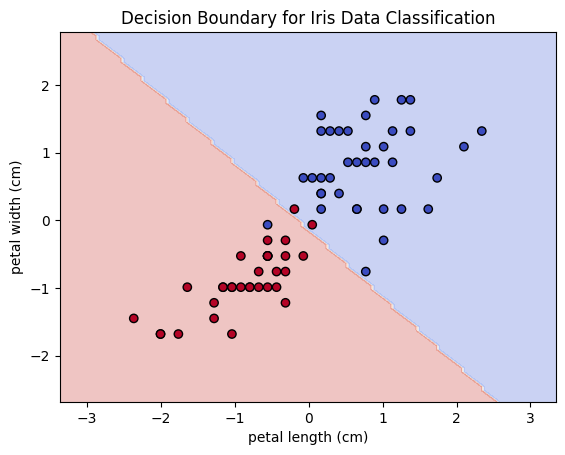

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(model_2d,X_train_scaled,response_method="predict",cmap="coolwarm",alpha=0.3)

plt.scatter(X_train_scaled.iloc[:,0],X_train_scaled.iloc[:,1],c=y_train.astype("category").cat.codes,cmap="coolwarm",edgecolor="k")

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Decision Boundary for Iris Data Classification")

plt.show()

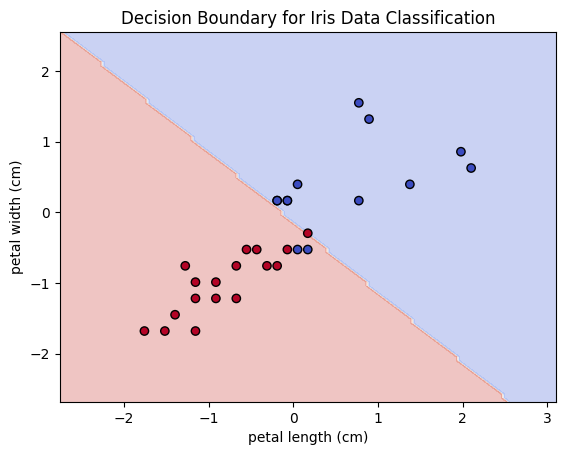

In [23]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(model_2d,X_test_scaled,response_method="predict",cmap="coolwarm",alpha=0.3)

plt.scatter(X_test_scaled.iloc[:,0],X_test_scaled.iloc[:,1],c=y_test.astype("category").cat.codes,cmap="coolwarm",edgecolor="k")

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Decision Boundary for Iris Data Classification")

plt.show()

# Binary Models for Multiclass Classification

In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# multinomial logistic regression
model_multi = LogisticRegression(solver="lbfgs")

model_multi.fit(X_train_scaled, y_train)

print("Accuracy:", model_multi.score(X_test_scaled, y_test))
y_pred_multi = model_multi.predict(X_test_scaled)


Accuracy: 1.0


### One-vs-Rest Strategy

We train 3 classifiers:

Class 0 vs others

Class 1 vs others

Class 2 vs others

In [25]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

ovr_model = OneVsRestClassifier(LogisticRegression())

ovr_model.fit(X_train_scaled, y_train)

print("OvR Accuracy:", ovr_model.score(X_test_scaled, y_test))
y_pred_ovr = ovr_model.predict(X_test_scaled)


OvR Accuracy: 0.9111111111111111


### One-vs-One Strategy

Trains a classifier for every pair of classes.

setosa vs versicolor

setosa vs virginica

versicolor vs virginica

Total = 3 classifiers.

In [26]:
from sklearn.multiclass import OneVsOneClassifier

ovo_model = OneVsOneClassifier(LogisticRegression())

ovo_model.fit(X_train_scaled, y_train)

print("OvO Accuracy:", ovo_model.score(X_test_scaled, y_test))
y_pred_ovo = ovo_model.predict(X_test_scaled)


OvO Accuracy: 1.0


In [27]:
# Combine predictions in a DataFrame for comparison
pred_df = pd.DataFrame({
    "True": y_test,
    "Multiclass": y_pred_multi,
    "OvR": y_pred_ovr,
    "OvO": y_pred_ovo
}).reset_index(drop=True)
pred_df

,True,Multiclass,OvR,OvO
0,1,1,1,1
1,0,0,0,0
2,2,2,2,2
3,1,1,1,1
4,1,1,1,1
5,0,0,0,0
6,1,1,1,1
7,2,2,2,2
8,1,1,1,1
9,1,1,1,1


# Model Evaluation and Selection
How can we evaluate a model 

■ Accuracy

– Classifier accuracy: predicting class label

– Predictor accuracy: guessing value of predicted attributes

■ Speed

– Time to construct the model (training time)

– Time to use the model (classification/prediction time)

■ Robustness

– Handling noise and missing values

■ Scalability

– Eefficiency in disk resident databases

■ Interpretability

– Understanding and insight provided by the model

■ Other measures Model Size 


# Misclassification Rate (0/1 Loss):

The 0–1 loss is defined as:

$$
\mathcal{L}_{0/1}(h) = \frac{1}{n} \sum_{i=1}^{n} \Big( 1 - \delta_{h(\mathbf{x}_i), y_i} \Big)
$$


- $h(x_i)$: Prediction of the model h for input $(x_i)$.  
- $y_i$: True label of the \(i\)-th data point.  
- $\delta_{h(\mathbf{x}_i), y_i}$: Kronecker delta, acting as an indicator:

$$
\delta_{h(\mathbf{x}_i), y_i} =
\begin{cases}
1 & \text{if } h(\mathbf{x}_i) = y_i \\
0 & \text{if } h(\mathbf{x}_i) \neq y_i
\end{cases}
$$

- $1 - \delta_{h(\mathbf{x}_i), y_i}$: Flips the indicator:

$$
1 - \delta_{h(\mathbf{x}_i), y_i} =
\begin{cases}
0 & \text{if correct prediction} \\
1 & \text{if incorrect prediction}
\end{cases}
$$

- $\sum_{i=1}^{n}$: Sum over all \(n\) samples, counting misclassifications.  
- $\frac{1}{n}$: Averages over the dataset, giving the fraction of mistakes.


- Each sample contributes **0** if predicted correctly and **1** if wrong.  
- Summing over all samples and dividing by \(n\) gives the **proportion of misclassified points**.

$$
\mathcal{L}_{0/1}(h) = \text{Fraction of mistakes made by the classifier } h
$$



1. 0–1 loss is **binary per sample**: either 0 (correct) or 1 (wrong).  
2. It is **non-differentiable**, making it unsuitable for gradient-based optimization.  
3. Directly related to accuracy:

$$
\text{Accuracy} = 1 - \mathcal{L}_{0/1}(h)
$$

### Though this is not enough if Classes are Imbalanced 

Suppose you have  two classes:

Class A: 95% of the data

Class B: 5% of the data

If our classifier always predicts Class A, here’s what happens:

Accuracy = fraction correct = 95% (because it “gets” all Class A points right)

But the classifier never identifies Class B, which might be the critical class you actually care about.

# Confisuion Matrix
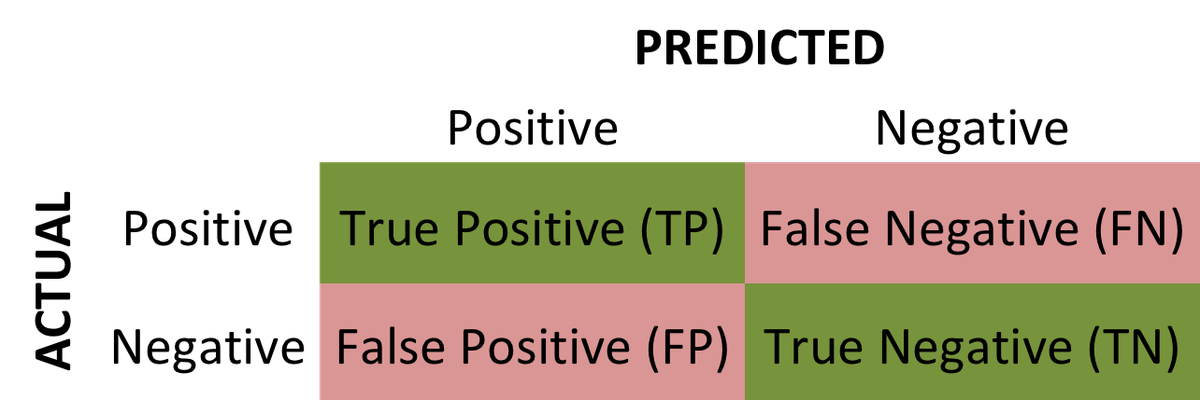

● $TP - True Positive$  • Number of points with y = 1 and are classified as ŷ = 1

● $TN - True Negative$   • Number of points with y = 0 and are classified as ŷ = 0

● $FP - False Positive$   • Number of points with y = 0 and are classified as ŷ = 1

● $FN- False Negative$   • Number of points with y = 1 and are classified as ŷ = 0

---

## 1. Accuracy

Fraction of correct predictions (both positive and negative):

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

## 2. Error Rate

Fraction of incorrect predictions:

$$
\text{Error Rate} = \frac{FP + FN}{TP + TN + FP + FN} = 1 - \text{Accuracy}
$$

## 3. Precision (Positive Predictive Value)

Of all samples predicted positive, how many are actually positive:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

## 4. Recall (Sensitivity / True Positive Rate)

Of all actual positives, how many did we correctly predict:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$
## 5. $F_\beta$-Score

Weighted harmonic mean of precision and recall. $\beta > 1$ emphasizes recall, $\beta < 1$ emphasizes precision:

$$
F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}
$$


## 6. F1-Score

Harmonic mean of precision and recall:

$$
\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$



- **F1-Score** is the special case when $\beta = 1$.


## 7. Specificity (True Negative Rate)

Of all actual negatives, how many did we correctly predict:

$$
\text{Specificity} = \frac{TN}{TN + FP}
$$


## 8. Notes

- **Accuracy** and **Error Rate** are simple overall measures.  
- **Precision, Recall, F\(_\beta\), and F1** are better for **imbalanced datasets**.  
- **Specificity** complements Recall by measuring performance on the negative class.
- We want high Specificity and high Sensitivity (=1, Ideally) but unrealistic.
  
 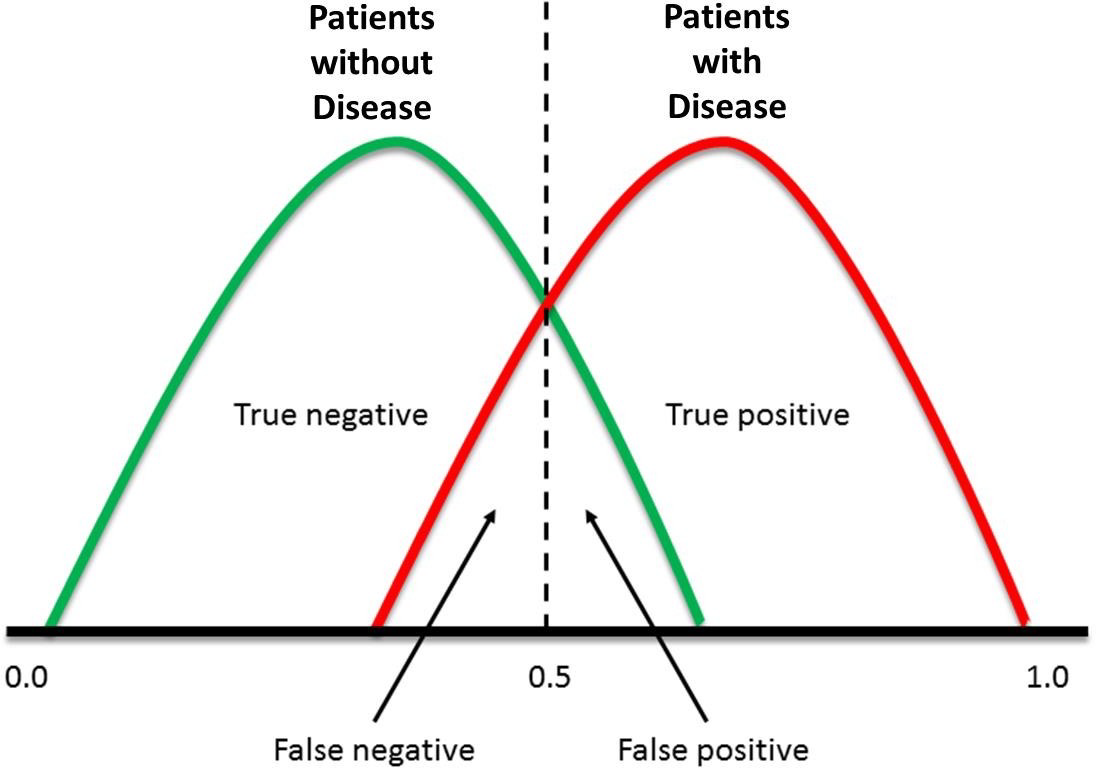
 
**Precision, Recall and F1-score are asymmetric**. Get a different result if the classes are switched.

Matthew’s correlation coefficient determines the correlation between true class and predicted class. The higher the correlation between true and predicted values, the better the prediction.

 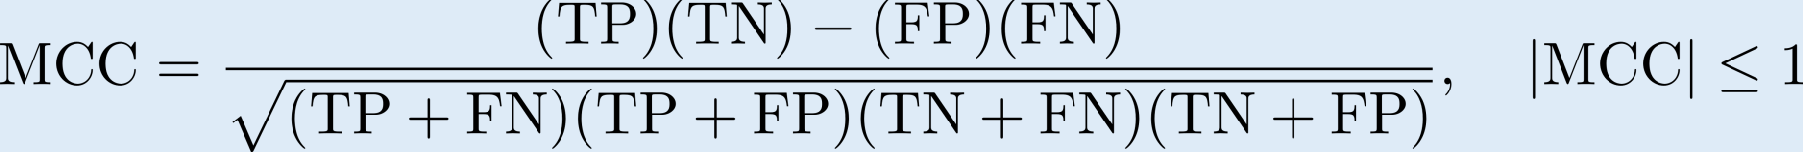

- MCC=1 when FP = FN = 0 (Perfect classification)
- MCC=-1 when TP = TN = 0 (Perfect misclassification)
- MCC=0; Performance of classifier is not better than a random classifier (flip coin)
- MCC is symmetric by design

**11-point Average Precision:**
- Adjust threshold of the classifier such that the recall takes the following 11 values 0.0, 0.1.,…, 0.9, 1.0.
- For each value of the recall, determine the precision and find the average value of precision,
referred to as average precision (AP).
- This is just uniformly-spaced sampling of Precision-Recall curve and taking average value.

**The Breakeven Point:**
- Compute precision as a function of recall for different values of thresholds.
- When Precision = Recall, we have a breakeven.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,fbeta_score,confusion_matrix,roc_curve,roc_auc_score)
X = df_binary.drop(columns="species")
y = df_binary["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
# Accuracy & Error Rate
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

# Precision, Recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)  # sensitivity
f1 = f1_score(y_test, y_pred)
fbeta = fbeta_score(y_test, y_pred, beta=2)  # example: beta=2, favors recall

# Specificity
specificity = TN / (TN + FP)

print(f"Accuracy: {accuracy:.3f}")
print(f"Error Rate: {error_rate:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")

print(f"F1-Score: {f1:.3f}")
print(f"F2-Score: {fbeta:.3f}")

# For multi-class datasets: micro & macro averaging (optional)
# precision_micro = precision_score(y_test, y_pred, average='micro')
# precision_macro = precision_score(y_test, y_pred, average='macro')
# recall_micro = recall_score(y_test, y_pred, average='micro')
# recall_macro = recall_score(y_test, y_pred, average='macro')

Accuracy: 0.900
Error Rate: 0.100
Precision: 0.938
Recall (Sensitivity): 0.882
Specificity: 0.923
F1-Score: 0.909
F2-Score: 0.893


## Area Under the Curve (AUC) & Receiver Operating Characteristic (ROC) Curve:
- used to evaluate the performance of a binary classifier
  
-Plot of TPR (Sensitivity) against FPR (1 – Specificity) for different values of threshold (shows the trade off).
- Also referred to as Sensitivity-(1-Specificity) plot.


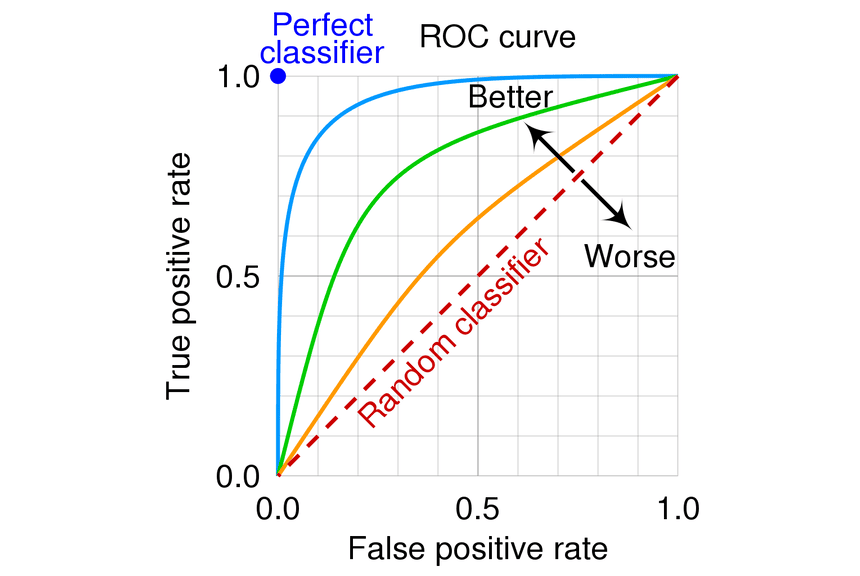
Threshold of 0.0, every case is diagnosed as positive.
- Se= TPR = 1
- FPR = 1
- Sp= 0
Threshold of 1.0, every case is diagnosed as negative.
- Se= TPR = 0
- FPR = 0
- Sp= 1
-TPR (Sensitivity): how many correct positive results
occur among all positive samples.
- FPR (1 – Specificity): how many incorrect positive results occur among all negative samples.
- The best possible prediction method
- Se = Sp = 1 (Upper left corner of ROC space)
-Random guess; a point along a diagonal line (the so-called line of no-discrimination), No Power!
-Area Under the ROC Curve, abbreviated as (AUC) quantifies the power of the classifier.

| Patient | Actual | Probability | Threshold 0.9 | Threshold 0.7 | Threshold 0.5 | Threshold 0.3 | Threshold 0.2 |
|---------|-------|------------|---------------|---------------|---------------|---------------|---------------|
| 1       | 1     | 0.9        | 1             | 1             | 1             | 1             | 1             |
| 2       | 0     | 0.8        | 0             | 0             | 1             | 1             | 1             |
| 3       | 1     | 0.7        | 0             | 1             | 1             | 1             | 1             |
| 4       | 0     | 0.4        | 0             | 0             | 0             | 0             | 0             |
| 5       | 1     | 0.3        | 0             | 0             | 0             | 1             | 1             |
| 6       | 0     | 0.2        | 0             | 0             | 0             | 0             | 1             |

| Metric / Threshold | 0.9 | 0.7 | 0.5 | 0.3 | 0.2 |
|------------------|-----|-----|-----|-----|-----|
| TP               | 1   | 2   | 2   | 3   | 3   |
| FP               | 0   | 0   | 1   | 1   | 2   |
| FN               | 2   | 1   | 1   | 0   | 0   |
| TN               | 3   | 3   | 2   | 2   | 1   |
| Sensitivity (Se) | 0.333 | 0.667 | 0.667 | 1.0 | 1.0 |
| Specificity (Sp) | 1.0   | 1.0   | 0.667 | 0.667 | 0.333 |

Predictions table:


,Patient,Actual,Probability,Threshold 0.9,Threshold 0.7,Threshold 0.5,Threshold 0.3,Threshold 0.2
0,1,1,0.461656,0,0,0,1,1
1,2,1,0.912907,1,1,1,1,1
2,3,1,0.985518,1,1,1,1,1
3,4,0,0.013905,0,0,0,0,0
4,5,0,0.045260,0,0,0,0,0
5,6,0,0.044400,0,0,0,0,0
6,7,0,0.510295,0,0,1,1,1
7,8,1,0.984135,1,1,1,1,1
8,9,0,0.010630,0,0,0,0,0
9,10,0,0.060654,0,0,0,0,0



Metrics table:


,0.9,0.7,0.5,0.3,0.2
TP,7.000000,9.000000,12.000000,13.000000,13.000000
FP,0.000000,0.000000,2.000000,3.000000,3.000000
FN,6.000000,4.000000,1.000000,0.000000,0.000000
TN,17.000000,17.000000,15.000000,14.000000,14.000000
Sensitivity (Se),0.538462,0.692308,0.923077,1.000000,1.000000
Specificity (Sp),1.000000,1.000000,0.882353,0.823529,0.823529


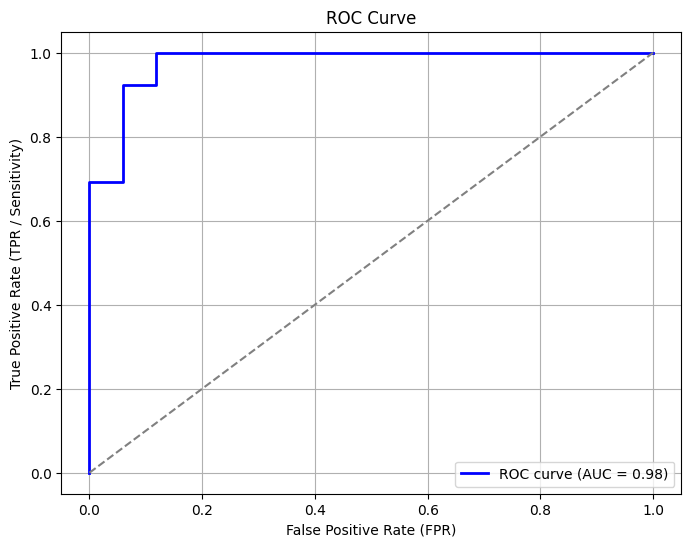

In [29]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Keep only two species for binary classification
df_binary = df[df["species"].isin(["virginica", "versicolor"])]
X = df_binary.drop(columns="species")
y = df_binary["species"]

# Convert species to 0/1
lb = LabelBinarizer()
y = lb.fit_transform(y).ravel()  # 0 = 'versicolor', 1 = 'virginica'

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1 ('virginica')
y_actual = y_test  # numeric 0/1 labels

# -----------------------------
# Thresholds to analyze
thresholds = [0.9, 0.7, 0.5, 0.3, 0.2]

# Prediction table
pred_table = pd.DataFrame({
    'Patient': np.arange(1, len(y_test)+1),
    'Actual': y_actual,
    'Probability': y_prob
})

for t in thresholds:
    pred_table[f'Threshold {t}'] = (y_prob >= t).astype(int)

# Metrics table
metrics = pd.DataFrame(index=['TP','FP','FN','TN','Sensitivity (Se)','Specificity (Sp)'],
                       columns=[str(t) for t in thresholds])

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    TP = np.sum((preds == 1) & (y_actual == 1))
    FP = np.sum((preds == 1) & (y_actual == 0))
    FN = np.sum((preds == 0) & (y_actual == 1))
    TN = np.sum((preds == 0) & (y_actual == 0))
    Sens = TP / (TP + FN) if (TP + FN) > 0 else 0
    Spec = TN / (TN + FP) if (TN + FP) > 0 else 0
    metrics[str(t)] = [TP, FP, FN, TN, Sens, Spec]

# Display tables
print("Predictions table:")
display(pred_table)
print("\nMetrics table:")
display(metrics)

# -----------------------------
# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_actual, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')


plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## K-Nearest Neighbors 

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier

## Load Dataset
We are using Obesity DataSet

In [31]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print(df.shape)
df.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Exploratory Data Analysis (EDA)
### Dataset info

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

### Summary statistics

In [33]:
df.describe()


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Check class distribution

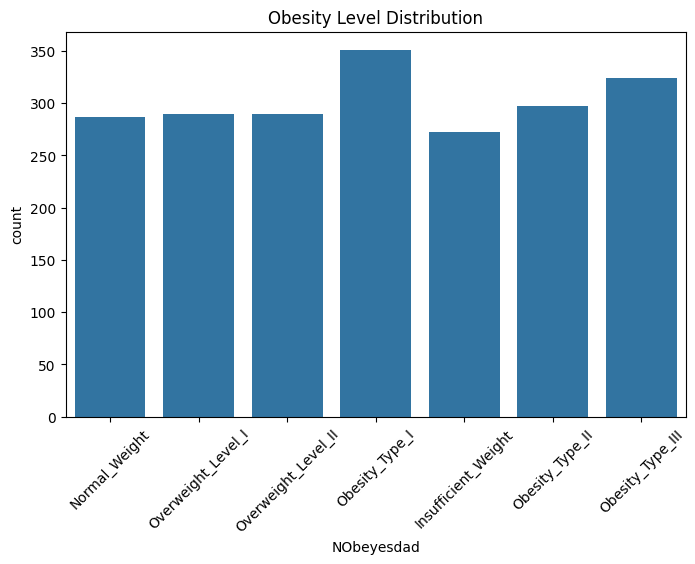

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x='NObeyesdad', data=df)
plt.xticks(rotation=45)
plt.title("Obesity Level Distribution")
plt.show()


### Correlation heatmap (numeric features)

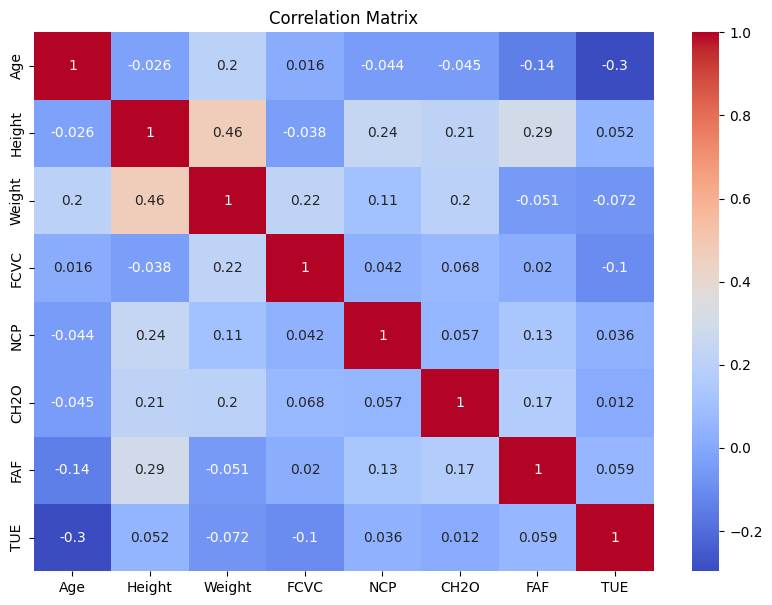

In [35]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


## Data Cleaning
### Check missing values

In [36]:
print(df.isnull().sum())


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


## Remove duplicates

In [37]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 24


## Encode Categorical Variables

In [38]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


## Feature / Target Split

In [39]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Feature Scaling

In [40]:
scaler = StandardScaler()
# Fit scaler ONLY on training data
X_train_scaled =scaler.fit_transform(X_train)

# Transform test data
X_test_scaled =scaler.transform(X_test)


### KNN

In [41]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)




,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [42]:
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.8660287081339713


In [43]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8660287081339713
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        59
           1       0.86      0.49      0.62        61
           2       0.90      0.91      0.91        70
           3       1.00      0.95      0.98        64
           4       0.94      1.00      0.97        60
           5       0.78      0.82      0.80        55
           6       0.80      0.88      0.83        49

    accuracy                           0.87       418
   macro avg       0.86      0.86      0.86       418
weighted avg       0.87      0.87      0.86       418



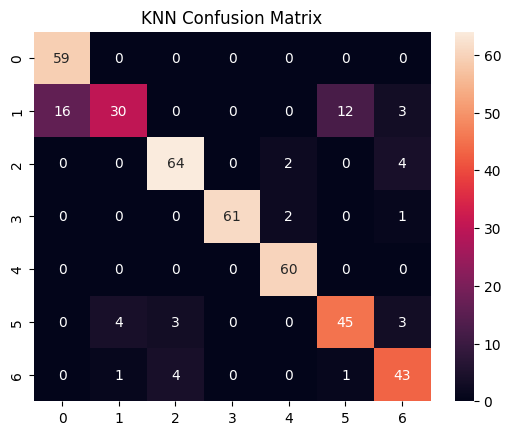

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d")
plt.title("KNN Confusion Matrix")
plt.show()


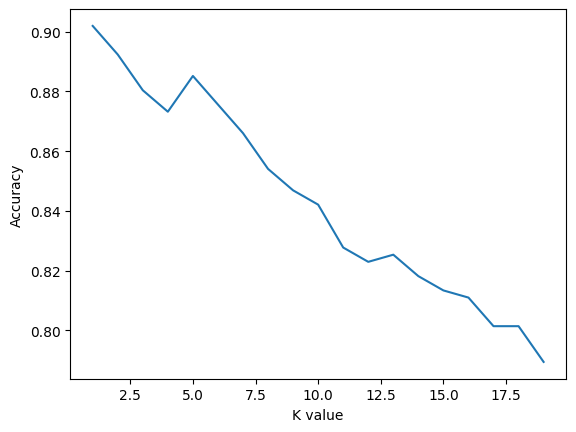

In [45]:
scores = []

for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test,pred))

plt.plot(range(1,20), scores)
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.show()
